# 6 - Synthèse comparative

Ce notebook ne calcule rien de nouveau : il relit les métriques et les prédictions sauvées
par les notebooks 02 à 05 (tous évalués **exactement pareil** via `outils_mspr`) et met tout
côte à côte. Trois niveaux de lecture :

1. **Par usine** — le niveau de décision opérationnel : quel modèle déployer dans quelle usine ;
2. **Global recombiné** — on concatène les prédictions U1 + U2 (707 machines de test) pour
   mesurer la performance sur le **parc complet** MECHA ;
3. **Sensibilité au protocole** — les chiffres bougent-ils si on écrête le RUL vrai à 125 ?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import outils_mspr as outils

MODELES = ['baseline', 'rf', 'hgb', 'lstm']
NOMS = {'baseline': 'Baseline linéaire', 'rf': 'Random Forest',
        'hgb': 'HGB (boosting)', 'lstm': 'LSTM'}

with open(outils.FICHIER_METRIQUES, encoding='utf-8') as f:
    METRIQUES = json.load(f)

## 1. Résultats par usine

### Régression RUL (RMSE/MAE/NASA : plus bas = mieux, R² : plus haut = mieux)

`NASA moyen` = score NASA total divisé par le nombre de machines (200 en U1, 507 en U2),
sinon l'Usine 2 semblerait "pire" juste parce qu'elle a plus de machines.

In [2]:
def tableau(tache, colonnes):
    lignes = {}
    for m in MODELES:
        ligne = {}
        for u in [1, 2]:
            met = METRIQUES[m][tache][f'usine{u}']
            for c in colonnes:
                ligne[(f'Usine {u}', c)] = met[c]
        lignes[NOMS[m]] = ligne
    return pd.DataFrame(lignes).T.round(3)

tableau('regression', ['RMSE', 'MAE', 'R2', 'NASA_moyen'])

Usine 1                           Usine 2                 \
                     RMSE     MAE     R2 NASA_moyen    RMSE     MAE     R2   
Baseline linéaire  22.548  18.134  0.704     16.690  33.940  26.394  0.608   
Random Forest      18.897  14.252  0.792      6.848  28.665  20.758  0.720   
HGB (boosting)     18.621  13.993  0.798      7.126  28.287  20.416  0.728   
LSTM               17.130  13.111  0.829      5.972  28.421  20.634  0.725   

                              
                  NASA_moyen  
Baseline linéaire     64.353  
Random Forest         32.179  
HGB (boosting)        29.812  
LSTM                  27.832

### Classification `at_risk` (tout : plus haut = mieux)

In [3]:
tableau('classification', ['f1', 'recall', 'precision', 'roc_auc'])

Usine 1                          Usine 2                   \
                       f1 recall precision roc_auc      f1 recall precision   
Baseline linéaire   0.884  0.933     0.840   0.986   0.826  0.956     0.727   
Random Forest       0.851  0.822     0.881   0.989   0.876  0.930     0.828   
HGB (boosting)      0.860  0.889     0.833   0.986   0.853  0.965     0.764   
LSTM                0.946  0.978     0.917   0.997   0.882  0.982     0.800   

                           
                  roc_auc  
Baseline linéaire   0.981  
Random Forest       0.987  
HGB (boosting)      0.990  
LSTM                0.995

## 2. Global recombiné — la performance sur le parc complet (707 machines)

L'approche V2 = un modèle **par usine**. Pour juger la solution au niveau de l'entreprise
(et pouvoir la comparer un jour à une stratégie « un seul modèle pour tout le parc »),
on rassemble les prédictions des deux usines et on recalcule les métriques sur les
707 machines : c'est ce qu'obtiendrait MECHA en déployant mes deux modèles spécialisés
sur l'ensemble du parc.

In [4]:
lignes_reg, lignes_clf = {}, {}
PRED_GLOBALES = {}
for m in MODELES:
    p1 = outils.charger_predictions(m, 'regression', 1)
    p2 = outils.charger_predictions(m, 'regression', 2)
    p = pd.concat([p1, p2], ignore_index=True)
    PRED_GLOBALES[m] = p
    lignes_reg[NOMS[m]] = outils.resultats_regression(p['y_true'], p['y_pred'], afficher=False)

    c1 = outils.charger_predictions(m, 'classification', 1)
    c2 = outils.charger_predictions(m, 'classification', 2)
    c = pd.concat([c1, c2], ignore_index=True)
    lignes_clf[NOMS[m]] = outils.resultats_classification(
        c['y_true'], c['y_pred'], c['y_proba'], afficher=False)

global_reg = pd.DataFrame(lignes_reg).T[['RMSE', 'MAE', 'R2', 'NASA_total']].round(3)
global_clf = pd.DataFrame(lignes_clf).T[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(3)
print("=== Régression RUL — 707 machines ===")
global_reg

=== Régression RUL — 707 machines ===


,RMSE,MAE,R2,NASA_total
Baseline linéaire,31.143,24.057,0.628,35964.725
Random Forest,26.273,18.918,0.735,17684.387
HGB (boosting),25.921,18.599,0.742,16539.863
LSTM,25.734,18.505,0.746,15305.191


In [5]:
print("=== Classification at_risk — 707 machines ===")
global_clf

=== Classification at_risk — 707 machines ===


,accuracy,precision,recall,f1,roc_auc
Baseline linéaire,0.919,0.755,0.950,0.841,0.982
Random Forest,0.939,0.841,0.899,0.869,0.987
HGB (boosting),0.928,0.781,0.943,0.855,0.988
LSTM,0.950,0.830,0.981,0.899,0.995


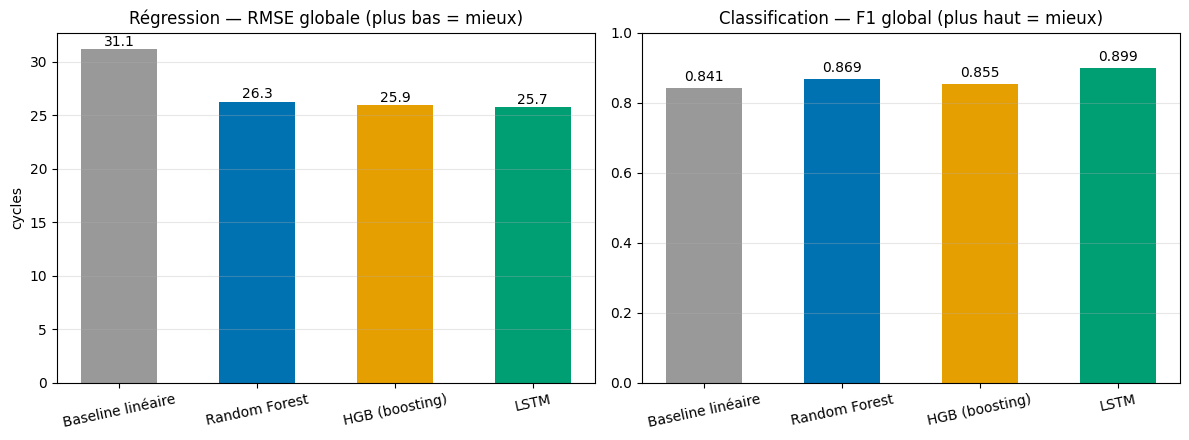

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
couleurs = [outils.COULEURS[m] for m in MODELES]

rmse = [lignes_reg[NOMS[m]]['RMSE'] for m in MODELES]
axes[0].bar([NOMS[m] for m in MODELES], rmse, color=couleurs, width=0.55)
axes[0].set_title('Régression — RMSE globale (plus bas = mieux)')
axes[0].set_ylabel('cycles')
for i, v in enumerate(rmse):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center')

f1 = [lignes_clf[NOMS[m]]['f1'] for m in MODELES]
axes[1].bar([NOMS[m] for m in MODELES], f1, color=couleurs, width=0.55)
axes[1].set_title('Classification — F1 global (plus haut = mieux)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

for ax in axes:
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=12)
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'synthese_globale.png', dpi=120)
plt.show()

## 3. Sensibilité au protocole : et si on écrête le RUL vrai à 125 ?

Les modèles sont entraînés sur un RUL plafonné à 125 → ils ne peuvent pas prédire plus.
Or certaines machines du test ont un RUL vrai > 125 : sur elles, l'erreur est mécanique,
quel que soit le modèle. Certains protocoles de la littérature écrêtent donc aussi le RUL
vrai. Les deux conventions se défendent — ce qui compte c'est de comparer **à convention
identique**. D'où ce tableau : mes chiffres dans les deux conventions.

In [7]:
lignes = {}
for m in MODELES:
    p = PRED_GLOBALES[m]
    y_ecrete = np.clip(p['y_true'], 0, outils.RUL_MAX)
    met = outils.resultats_regression(y_ecrete, p['y_pred'], afficher=False)
    lignes[NOMS[m]] = {'RMSE (écrêté)': met['RMSE'], 'MAE (écrêté)': met['MAE'],
                       'R2 (écrêté)': met['R2'], 'NASA_total (écrêté)': met['NASA_total']}

nb_sup = int((PRED_GLOBALES['rf']['y_true'] > outils.RUL_MAX).sum())
print(f"{nb_sup} machines de test sur 707 ont un RUL vrai > 125")
pd.DataFrame(lignes).T.round(2)

150 machines de test sur 707 ont un RUL vrai > 125


,RMSE (écrêté),MAE (écrêté),R2 (écrêté),NASA_total (écrêté)
Baseline linéaire,22.33,17.89,0.72,9624.81
Random Forest,17.36,12.75,0.83,4737.61
HGB (boosting),17.16,12.43,0.83,4841.92
LSTM,16.54,12.34,0.85,5020.85


## 4. Conclusions

**La hiérarchie confirme la théorie.** Baseline < forêt < boosting < LSTM en régression
globale (RMSE 31.1 → 26.3 → 25.9 → 25.7) ; en classification le LSTM domine nettement
(F1 0.899, recall 0.981, AUC 0.995) — la temporalité paie sur les deux tâches.

**L'approche par usine tient ses promesses.** Chaque modèle apprend un problème homogène
(1 régime en U1, 6 régimes normalisés en U2) et le recombiné sur les 707 machines reste
excellent — avec en plus la **lisibilité opérationnelle** : MECHA sait que l'Usine 1 est
prédite à ±17 cycles et l'Usine 2 à ±28, là où un chiffre global unique masquerait cette
différence de fiabilité. Le score NASA global (15 305 pour le LSTM) montre que les erreurs
restantes sont majoritairement du côté « prudent », pas du côté dangereux.

**Attention aux conventions de mesure.** L'écrêtage du RUL vrai au test change beaucoup
les chiffres (RMSE 25.7 → 16.5, section 3) : toute comparaison avec d'autres travaux ou
avec la littérature doit se faire à convention identique — c'est pour ça qu'elle est
mesurée et documentée ici.

**Recommandation de déploiement MECHA :**

| Tâche | Modèle recommandé | Pourquoi |
|---|---|---|
| Classification `at_risk` (alerte) | **LSTM** | F1 0.899, recall 0.981 : ~2 machines à risque manquées sur 100, precision correcte |
| Régression RUL (planification) | **LSTM**, repli HGB | meilleure RMSE ET meilleur score NASA ; le HGB fait presque aussi bien pour une fraction du coût d'entraînement |
| Usine 1 seule (parc simple) | HGB voire baseline | sur un problème simple, le tabulaire est quasi au niveau du LSTM pour bien moins cher |

Garde-fou permanent : suivre le **PHM08 dangereux** (prédictions trop optimistes) en
production — c'est lui qui mesure le risque de panne non planifiée, pas la RMSE.